# INTD 555 Project 2: Binary Classification


This project builds a binary classification model to predict whether a flame will be extinguished using acoustic signals. The dataset includes physical and acoustic measurements collected during controlled fire extinguishing experiments.

In [81]:
'''
Upload the file Acoustic_Extinguisher_Fire_Dataset.xlsx
Import required libraries
'''
# Uncomment line below to remove existing cloned repository to allow clean rerun of the project
!rm -rf INTD555

# Clone repository to import data file
!git clone https://github.com/emathes2/INTD555.git

# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model preparation
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Cloning into 'INTD555'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 42 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 1.17 MiB | 11.70 MiB/s, done.
Resolving deltas: 100% (2/2), done.


# Dataset Description

This project uses the Acoustic Fire Extinguisher dataset, which contains experimental data on extinguishing flames using sound waves. The dataset was generated through controlled tests using a sound wave fire-extinguishing system equipped with subwoofers, amplifiers, and measurement instruments such as an anemometer and decibel meter.

A total of 17,442 experiments were conducted using different fuel types, flame sizes, and sound wave conditions. The dataset includes six input features and one target variable:

* `SIZE`: Represents the size of the flame (encoded numerically)
* `FUEL`: Type of fuel used (gasoline, kerosene, thinner, LPG)
* `DISTANCE`: Distance between the sound source and the flame (cm)
* `DESIBEL`: Sound intensity (dB)
* `AIRFLOW`: Airflow generated by the sound waves (m/s)
* `FREQUENCY`: Frequency of the sound waves (Hz)

The target variable is:

* `STATUS`: Indicates whether the flame was extinguished (1) or not (0)

The objective of this project is to build a binary classification model to predict whether a flame will be extinguished based on these input features.

In [82]:
# Load the dataset from the repository into a DataFrame
aef = pd.read_excel('INTD555/Project2/Acoustic_Extinguisher_Fire_Dataset.xlsx')

# Display the first 10 rows to preview the structure of the data
aef.head(10)

,SIZE,FUEL,DISTANCE,DESIBEL,AIRFLOW,FREQUENCY,STATUS
0,1,gasoline,10,96,0.0,75,0
1,1,gasoline,10,96,0.0,72,1
2,1,gasoline,10,96,2.6,70,1
3,1,gasoline,10,96,3.2,68,1
4,1,gasoline,10,109,4.5,67,1
5,1,gasoline,10,109,7.8,66,1
6,1,gasoline,10,103,9.7,65,1
7,1,gasoline,10,95,12.0,60,1
8,1,gasoline,10,102,13.3,55,1
9,1,gasoline,10,93,15.4,52,1


In [83]:
# Display summary information about the dataset (data types, non-null counts)
aef.info()
print()

# Identify the unique categories present in the FUEL variable
print('Fuel types: ')
print(aef['FUEL'].unique())
print()

# Examine the distribution of the target variable (0 = no extinction, 1 = extinction)
print("Class distribution (STATUS):")
print(aef['STATUS'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17442 entries, 0 to 17441
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SIZE       17442 non-null  int64  
 1   FUEL       17442 non-null  object 
 2   DISTANCE   17442 non-null  int64  
 3   DESIBEL    17442 non-null  int64  
 4   AIRFLOW    17442 non-null  float64
 5   FREQUENCY  17442 non-null  int64  
 6   STATUS     17442 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 954.0+ KB

Fuel types: 
['gasoline' 'thinner' 'kerosene' 'lpg']

Class distribution (STATUS):
STATUS
0    0.502179
1    0.497821
Name: proportion, dtype: float64


The dataset is well-suited for classification as the target variable is binary and the observations are evenly distributed between the two classes.

# Exploratory Data Analysis (EDA)
Exploratory data analysis (EDA) is used to examine relationships between the features and the target variable. Visualizations are used to identify patterns in variables such as decibel level, frequency, and airflow, which may influence flame extinction outcomes.

## Boxplot (DESIBEL vs STATUS)
A boxplot is used to compare the distribution of a numerical feature across the two outcome classes. This allows observations of how variables such as decibel level differ between extinguished and non-extinguished flames, which may indicate their importance as predictors.

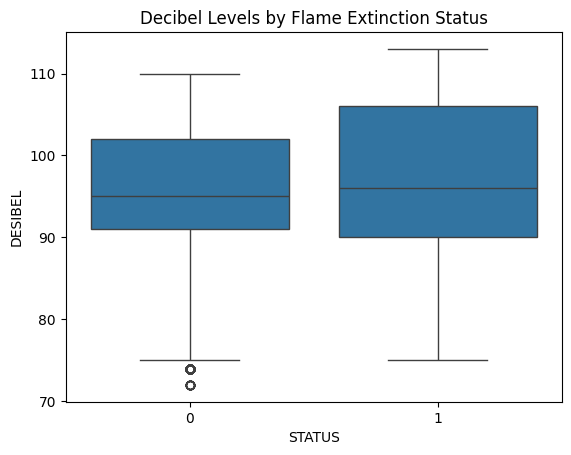

In [84]:
# Visualize the distribution of decibel levels across extinction outcomes
sns.boxplot(x='STATUS', y='DESIBEL', data=aef)

# Add a descriptive title to the plot
plt.title("Decibel Levels by Flame Extinction Status")

# Display the plot
plt.show()

The boxplot shows that higher decibel levels are generally associated with successful flame extinction (STATUS = 1). While there is overlap between the two classes, the median decibel level is slightly higher for extinguished flames, and the upper range extends further. This suggests that increased sound intensity may contribute to the likelihood of extinguishing a flame, although it is not the sole determining factor.

## Scatter plot (FREQUENCY vs AIRFLOW)

A scatter plot is used to examine the relationship between two numerical features and how they interact with the target variable. By visualizing frequency and airflow together, an assessment of whether combinations of these variables show separation between extinction outcomes.

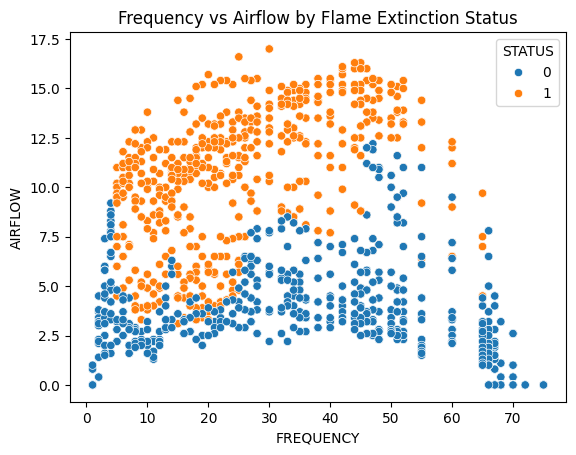

In [85]:
# Visualize the relationship between frequency and airflow, colored by extinction outcome
sns.scatterplot(x='FREQUENCY', y='AIRFLOW', hue='STATUS', data=aef)

# Add a descriptive title to the plot
plt.title("Frequency vs Airflow by Flame Extinction Status")

# Display the plot
plt.show()

The scatter plot reveals a noticeable separation between extinction outcomes based on airflow and frequency. Observations with higher airflow values are more frequently associated with successful extinction (STATUS = 1), while lower airflow values tend to correspond to non-extinction (STATUS = 0). This suggests that airflow, potentially in combination with frequency, plays an important role in determining whether a flame can be extinguished.

## Countplot (FUEL vs STATUS)

A count plot is used to analyze the relationship between a categorical feature and the target variable. This helps determine whether the distribution of extinction outcomes varies across different fuel types, indicating whether fuel type may influence the model’s predictions.

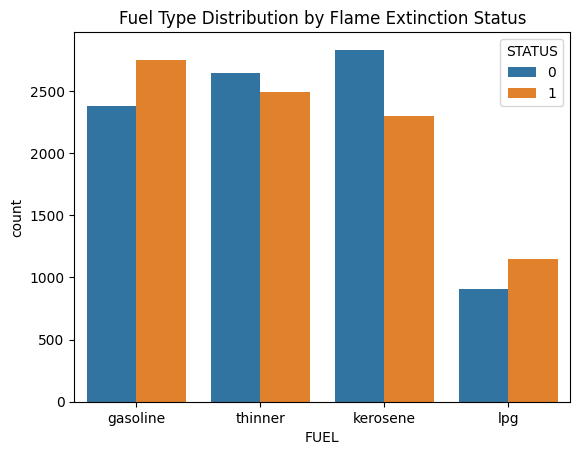

In [86]:
# Visualize the distribution of fuel types across extinction outcomes
sns.countplot(x='FUEL', hue='STATUS', data=aef)

# Add a descriptive title to the plot
plt.title("Fuel Type Distribution by Flame Extinction Status")

# Display the plot
plt.show()

The count plot shows that extinction outcomes vary slightly across different fuel types. While all fuel types exhibit both extinguished and non-extinguished cases, some fuels appear to have a higher proportion of successful extinguishing than others. This indicates that fuel type may influence extinction outcomes, although its effect is less pronounced compared to numerical variables such as airflow and decibel level.

Overall, the visualizations suggest that variables such as decibel level and airflow show stronger relationships with flame extinction, while fuel type appears to have a more limited influence.

# Train a Binary Classification Model
In this section, the dataset is split into training and testing sets to evaluate model performance on unseen data. A baseline classification model is then trained and assessed using standard evaluation metrics.

In [87]:
# Separate the input features from the target variable
X = aef.drop('STATUS', axis=1)
y = aef['STATUS']

# Convert the categorical FUEL variable into numeric dummy variables
X = pd.get_dummies(X, columns=['FUEL'], drop_first=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the baseline logistic regression model
model = LogisticRegression(max_iter=1000)

# Train the model using the training data
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [88]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using standard classification metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9065634852393236
Precision: 0.9190283400809717
Recall: 0.8952112676056339
F1 Score: 0.9069634703196348


The logistic regression model achieved strong performance, with accuracy and F1 scores above 0.90, indicating that it can effectively distinguish between extinguished and non-extinguished flames. Precision and recall are also well balanced, suggesting the model performs consistently across both classes.

However, logistic regression assumes a linear relationship between the features and the target variable, which may limit its ability to capture more complex patterns in the data.

The model could be improved by using more flexible algorithms such as Random Forest or by applying feature selection and hyperparameter tuning to better capture non-linear relationships.

# Improve the Model’s Performance (Feature Selection and Hyperparameter Tuning)
In this section, the baseline model is improved by applying feature selection and hyperparameter tuning, followed by training an alternative classification model. Random Forest is used as the alternative model because it can capture more complex, non-linear relationships than logistic regression.

In [89]:
# Train an initial Random Forest model to estimate feature importance
rf_initial = RandomForestClassifier(random_state=42)
rf_initial.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [90]:
# Create a table of feature importance scores for interpretation
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_initial.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
3,AIRFLOW,0.354279
1,DISTANCE,0.261218
4,FREQUENCY,0.150893
0,SIZE,0.100607
2,DESIBEL,0.080792
7,FUEL_thinner,0.021262
5,FUEL_kerosene,0.020947
6,FUEL_lpg,0.010002


In [91]:
# Select the top 5 most important features based on importance scores
selected_features = feature_importance['Feature'].head(5).tolist()

print("Selected features:", selected_features)

Selected features: ['AIRFLOW', 'DISTANCE', 'FREQUENCY', 'SIZE', 'DESIBEL']


Feature selection was performed using Random Forest feature importance scores. The most important predictors were retained to reduce the number of inputs and focus the model on variables that appear to contribute most strongly to flame extinction. This may improve model efficiency and reduce noise from less informative variables.

In [92]:
# Create reduced datasets using only the selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Perform grid search with cross-validation to find optimal model parameters
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_selected, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1 score:", grid_search.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation F1 score: 0.9319567513874232


Hyperparameter tuning was used to identify a better-performing set of Random Forest settings. Parameters such as the number of trees, maximum tree depth, and minimum split requirements were adjusted to improve generalization and optimize model performance.

In [93]:
# Train the final Random Forest model using the best parameters
rf_final = grid_search.best_estimator_
rf_final.fit(X_train_selected, y_train)

# Generate predictions using the tuned model
y_pred_rf = rf_final.predict(X_test_selected)

# Evaluate the tuned Random Forest model
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9352249928346231
Precision: 0.9433314253005152
Recall: 0.9284507042253521
F1 Score: 0.935831913685406


The tuned Random Forest model improved upon the baseline logistic regression model, achieving higher accuracy and F1 score. This indicates that the Random Forest model is better able to capture the underlying patterns in the data, likely due to its ability to model non-linear relationships and interactions between features.

Feature selection helped focus the model on the most important predictors, while hyperparameter tuning further enhanced performance by optimizing the model’s structure. Overall, this demonstrates that more flexible models can provide improved predictive performance compared to simpler linear approaches for this dataset.

# References

1.   Koklu, M., & Taspinar, Y. S. (2021). Determining the extinguishing status of fuel flames with sound wave by machine learning methods. *IEEE* Access, 9, 86207–86216. https://doi.org/10.1109/ACCESS.2021.3088612

2.   Scikit-learn developers. (n.d.). *RandomForestClassifier*. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

3.   Taspinar, Y. S., Koklu, M., & Altin, M. (2021). Classification of flame extinction based on acoustic oscillations using artificial intelligence methods. *Case Studies in Thermal Engineering*, 28, 101561. https://doi.org/10.1016/j.csite.2021.101561

3.   Taspinar, Y. S., Koklu, M., & Altin, M. (2022). Acoustic-driven airflow flame extinguishing system design and analysis of capabilities of low frequency in different fuels. *Fire Technology*. https://doi.org/10.1007/s10694-021-01208-9